# Hands-on Workshop: Data Collection and Cleaning

This notebook is the second lab, covering data cleaning and preprocessing steps using the Cafe Sales Dirty Dataset from Kaggle.

Link to the dataset: https://www.kaggle.com/datasets/ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training

Refer to week 2 slides for detailed introduction to the topic.

## Topics Covered:
1. Manual Data Manipulation in Matrix Form and Vector Transformations
2. Data Collection and Labelling
3. Dealing with Missing Data
4. Data Leakage and Spurious Correlations
5. Train/Validation/Test Splits in Practice

## Setup
First, let's install required packages and download the dataset.

In [2]:
# Install required packages if not already installed
%pip install -q pandas numpy matplotlib seaborn scikit-learn

# Option 1:
# Download the dataset (requires Kaggle API setup). If you have Kaggle API key set up, uncomment the following:
# !kaggle datasets download -d ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training
# !unzip cafe-sales-dirty-data-for-cleaning-training.zip

# Option 2:
# Download manually from the Kaggle link and place in the workspace

Note: you may need to restart the kernel to use updated packages.


In [3]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

In [4]:
# Set random seed for reproducibility
np.random.seed(42)

In [5]:
# Load the dataset
# Assuming the file is named 'dirty_cafe_sales.csv' in the current directory
df = pd.read_csv('dirty_cafe_sales.csv')
print("Dataset loaded successfully!")
print(f"Shape: {df.shape}")
df.head()

Dataset loaded successfully!
Shape: (10000, 8)


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11


## 1. Manual Data Manipulation in Matrix Form and Vector Transformations

In this section, we'll work with the data as matrices and perform vector operations manually to understand the underlying mathematics.

In [6]:
# Convert relevant columns to numeric matrices
subset_df = df[['Quantity', 'Price Per Unit', 'Total Spent']].copy()

# Handle missing values 
subset_df = subset_df.dropna()

# Convert to numeric, coercing errors to NaN
subset_df['Quantity'] = pd.to_numeric(subset_df['Quantity'], errors='coerce')
subset_df['Price Per Unit'] = pd.to_numeric(subset_df['Price Per Unit'], errors='coerce')
subset_df['Total Spent'] = pd.to_numeric(subset_df['Total Spent'], errors='coerce')
subset_df = subset_df.dropna()

In [7]:
# Convert to numpy matrix
data_matrix = subset_df.values
print("Data matrix shape:", data_matrix.shape)
print("First 5 rows of data matrix:")
print(data_matrix[:5])

Data matrix shape: (8544, 3)
First 5 rows of data matrix:
[[ 2.  2.  4.]
 [ 4.  3. 12.]
 [ 2.  5. 10.]
 [ 2.  2.  4.]
 [ 5.  4. 20.]]


In [8]:
# 1. Standardization (z-score normalization)
def manual_standardize(matrix):
    means = np.mean(matrix, axis=0)
    stds = np.std(matrix, axis=0)
    return (matrix - means) / stds

standardized_matrix = manual_standardize(data_matrix)
print("Standardized matrix (first 5 rows):")
print(standardized_matrix[:5])

Standardized matrix (first 5 rows):
[[-0.72066621 -0.74301912 -0.82157425]
 [ 0.68882723  0.03956907  0.51185984]
 [-0.72066621  1.60474543  0.17850132]
 [-0.72066621 -0.74301912 -0.82157425]
 [ 1.39357396  0.82215725  1.84529393]]


In [9]:
# 2. Min-Max scaling
def manual_minmax_scale(matrix):
    mins = np.min(matrix, axis=0)
    maxs = np.max(matrix, axis=0)
    return (matrix - mins) / (maxs - mins)

scaled_matrix = manual_minmax_scale(data_matrix)
print("Min-Max scaled matrix (first 5 rows):")
print(scaled_matrix[:5])

Min-Max scaled matrix (first 5 rows):
[[0.25       0.25       0.125     ]
 [0.75       0.5        0.45833333]
 [0.25       1.         0.375     ]
 [0.25       0.25       0.125     ]
 [1.         0.75       0.79166667]]


In [10]:
# Vector operations. Compute total spent manually
quantity_vector = data_matrix[:, 0]
price_vector = data_matrix[:, 1]
manual_total = quantity_vector * price_vector
print("Does manual total calculation match original?", np.allclose(manual_total, data_matrix[:, 2]))

Does manual total calculation match original? True


In [11]:
# 4. Matrix multiplication example using a transformation matrix
transformation_matrix = np.array([[1, 0, 0],  # quantity
                                  [0, 1, 0],  # price
                                  [1, 1, 0]]) # Sum of quantity and price

transformed = data_matrix @ transformation_matrix.T
print("Transformed matrix (first 5 rows):")
print(transformed[:5])

Transformed matrix (first 5 rows):
[[2. 2. 4.]
 [4. 3. 7.]
 [2. 5. 7.]
 [2. 2. 4.]
 [5. 4. 9.]]


## 2. Data Collection and Labelling

Data collection involves gathering data from various sources. In this case, our data comes from a single CSV file, but in practice, data might come from APIs, databases, web scraping, etc.

Labelling refers to assigning meaningful labels or categories to data points. Here, we'll explore the categorical variables and create labels.

In [12]:
# Data Collection
print("Data Source: Kaggle Dataset - Cafe Sales Dirty Data")
print("Collection Method: CSV download")
print("Data Volume:", len(df), "records")
print("Features:", list(df.columns))

Data Source: Kaggle Dataset - Cafe Sales Dirty Data
Collection Method: CSV download
Data Volume: 10000 records
Features: ['Transaction ID', 'Item', 'Quantity', 'Price Per Unit', 'Total Spent', 'Payment Method', 'Location', 'Transaction Date']


In [13]:
df.describe()

,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
count,10000,9667,9862,9821,9827,7421,6735,9841
unique,10000,10,7,8,19,5,4,367
top,TXN_1961373,Juice,5,3.0,6.0,Digital Wallet,Takeaway,UNKNOWN
freq,1,1171,2013,2429,979,2291,3022,159


In [14]:
# Data Labelling
# Explore categorical variables
categorical_cols = ['Item', 'Payment Method', 'Location']
for col in categorical_cols:
    print(f"\n{col} unique values:")
    print(df[col].value_counts(dropna=False))


Item unique values:
Item
Juice       1171
Coffee      1165
Salad       1148
Cake        1139
Sandwich    1131
Smoothie    1096
Cookie      1092
Tea         1089
UNKNOWN      344
NaN          333
ERROR        292
Name: count, dtype: int64

Payment Method unique values:
Payment Method
NaN               2579
Digital Wallet    2291
Credit Card       2273
Cash              2258
ERROR              306
UNKNOWN            293
Name: count, dtype: int64

Location unique values:
Location
NaN         3265
Takeaway    3022
In-store    3017
ERROR        358
UNKNOWN      338
Name: count, dtype: int64


In [15]:
df[['Item', 'Price Per Unit']]

,Item,Price Per Unit
0,Coffee,2.0
1,Cake,3.0
2,Cookie,1.0
3,Salad,5.0
4,Coffee,2.0
...,...,...
9995,Coffee,2.0
9996,NaN,NaN
9997,Coffee,2.0
9998,Cookie,NaN


In [16]:
df['Item'].groupby(df['Price Per Unit']).count()

Price Per Unit
1.0        1105
1.5        1100
2.0        1188
3.0        2349
4.0        2249
5.0        1166
ERROR       182
UNKNOWN     156
Name: Item, dtype: int64

In [ ]:
# Create labels for items based on price categories

item_prices = df.groupby('Item')['Price Per Unit'].first()
item_prices.to_dict()

{'Cake': '3.0',
 'Coffee': '2.0',
 'Cookie': '1.0',
 'ERROR': '1.5',
 'Juice': '3.0',
 'Salad': '5.0',
 'Sandwich': '4.0',
 'Smoothie': '4.0',
 'Tea': '1.5',
 'UNKNOWN': '3.0'}

In [32]:
# Label items by price category
def categorize_price(price):
    if price <= 2.0:
        return 'Low'
    elif price <= 4.0:
        return 'Medium'
    else:
        return 'High'

df['Item_Price_Category'] = df['Item'].map(item_prices).apply(categorize_price)
print("Item price categories:")
print(df['Item_Price_Category'].value_counts())

Item price categories:
Item_Price_Category
Medium    4537
Low       3346
High      2117
Name: count, dtype: int64


In [19]:
# Label transactions by total spent
def categorize_total_spent(total):
    try:
        total = float(total)
        if total <= 5.0:
            return 'Small'
        elif total <= 10.0:
            return 'Medium'
        else:
            return 'Large'
    except:
        return 'Unknown'

df['Transaction_Size'] = df['Total Spent'].apply(categorize_total_spent)
print("Transaction size categories:")
print(df['Transaction_Size'].value_counts())

Transaction size categories:
Transaction_Size
Small      3480
Large      3295
Medium     2896
Unknown     329
Name: count, dtype: int64


In [20]:
# Label payment methods
payment_labels = {
    'Cash': 'Traditional',
    'Credit Card': 'Digital',
    'Debit Card': 'Digital',
    'Mobile Payment': 'Digital'
}
df['Payment_Type'] = df['Payment Method'].map(payment_labels).fillna('Unknown')
print("Payment type categories:")
print(df['Payment_Type'].value_counts())

Payment type categories:
Payment_Type
Unknown        5469
Digital        2273
Traditional    2258
Name: count, dtype: int64


In [21]:
# Display labelled data
print("Sample of labelled data:")
print(df[['Item', 'Item_Price_Category', 'Transaction_Size', 'Payment_Type']].head(10))

Sample of labelled data:
       Item Item_Price_Category Transaction_Size Payment_Type
0    Coffee                 Low            Small      Digital
1      Cake              Medium            Large  Traditional
2    Cookie                 Low          Unknown      Digital
3     Salad                High           Medium      Unknown
4    Coffee                 Low            Small      Unknown
5  Smoothie              Medium            Large      Digital
6   UNKNOWN                High           Medium      Unknown
7  Sandwich              Medium            Large  Traditional
8       NaN                High            Large      Unknown
9  Sandwich              Medium            Large      Unknown


## 3. Dealing with Missing Data

Missing data is common in real-world datasets. We'll explore different strategies for handling missing values.

What do we do when we have missing data in our target variable?

In [22]:
# Check for missing values
print("Missing values per column:")
missing_counts = df.isnull().sum()
print(missing_counts)

print("\nPercentage of missing values:")
print((missing_counts / len(df)) * 100)

Missing values per column:
Transaction ID            0
Item                    333
Quantity                138
Price Per Unit          179
Total Spent             173
Payment Method         2579
Location               3265
Transaction Date        159
Item_Price_Category       0
Transaction_Size          0
Payment_Type              0
dtype: int64

Percentage of missing values:
Transaction ID          0.00
Item                    3.33
Quantity                1.38
Price Per Unit          1.79
Total Spent             1.73
Payment Method         25.79
Location               32.65
Transaction Date        1.59
Item_Price_Category     0.00
Transaction_Size        0.00
Payment_Type            0.00
dtype: float64


In [23]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype
---  ------               --------------  -----
 0   Transaction ID       10000 non-null  str  
 1   Item                 9667 non-null   str  
 2   Quantity             9862 non-null   str  
 3   Price Per Unit       9821 non-null   str  
 4   Total Spent          9827 non-null   str  
 5   Payment Method       7421 non-null   str  
 6   Location             6735 non-null   str  
 7   Transaction Date     9841 non-null   str  
 8   Item_Price_Category  10000 non-null  str  
 9   Transaction_Size     10000 non-null  str  
 10  Payment_Type         10000 non-null  str  
dtypes: str(11)
memory usage: 859.5 KB


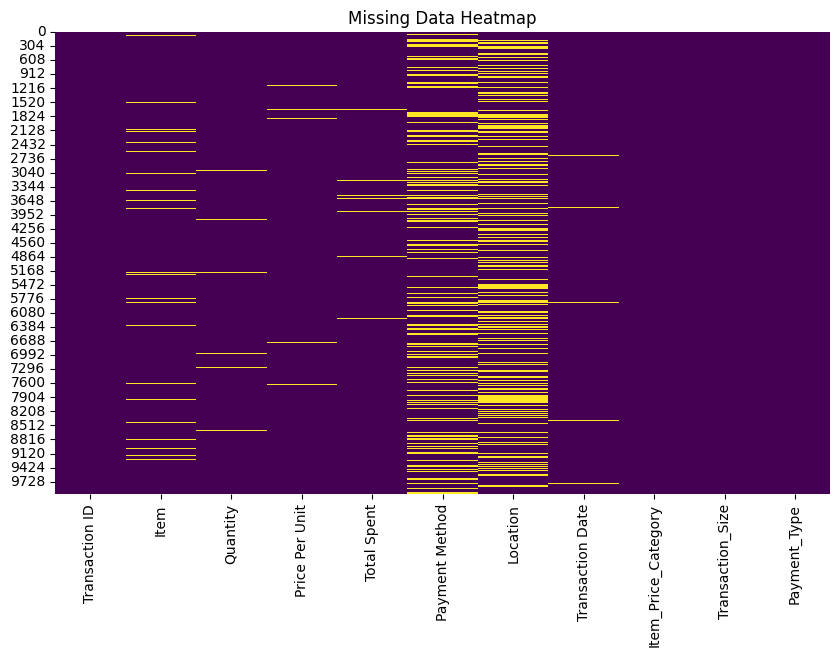

In [24]:
# Visualize missing data
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.show()

In [25]:
# Strategy 1: Drop missing values
df_dropna = df.dropna()
print(f"After dropping all missing values: {len(df_dropna)} records remaining")

After dropping all missing values: 4550 records remaining


In [26]:
# Strategy 2: Fill missing values
df_filled = df.copy()

# For numeric columns, fill with median
numeric_cols = ['Quantity', 'Price Per Unit', 'Total Spent']
for col in numeric_cols:
    # Convert to numeric first
    df_filled[col] = pd.to_numeric(df_filled[col], errors='coerce')
    median_val = df_filled[col].median()
    df_filled[col] = df_filled[col].fillna(median_val)
    print(f"Filled {col} missing values with median: {median_val}")

# For categorical columns, fill with mode
categorical_cols = ['Item', 'Payment Method', 'Location']
for col in categorical_cols:
    mode_val = df_filled[col].mode()[0]
    df_filled[col] = df_filled[col].fillna(mode_val)
    print(f"Filled {col} missing values with mode: {mode_val}")

Filled Quantity missing values with median: 3.0
Filled Price Per Unit missing values with median: 3.0
Filled Total Spent missing values with median: 8.0
Filled Item missing values with mode: Juice
Filled Payment Method missing values with mode: Digital Wallet
Filled Location missing values with mode: Takeaway


In [27]:
# Handle 'ERROR' and 'UNKNOWN' values
df_cleaned = df_filled.copy()
df_cleaned = df_cleaned.replace(['ERROR', 'UNKNOWN', 'None'], np.nan)

# Re-fill after replacing
for col in numeric_cols:
    df_cleaned[col] = pd.to_numeric(df_cleaned[col], errors='coerce')
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

print("After cleaning 'ERROR' and 'UNKNOWN':")
print("Missing values remaining:", df_cleaned.isnull().sum().sum())

After cleaning 'ERROR' and 'UNKNOWN':
Missing values remaining: 460


In [34]:
# Strategy 3: Advanced imputation - forward/backward fill for time series (if applicable)
# Since we have dates, we could sort by date and fill
df_cleaned['Transaction Date'] = pd.to_datetime(df_cleaned['Transaction Date'], errors='coerce')
df_sorted = df_cleaned.sort_values('Transaction Date')

# Forward fill for categorical data
df_ffill = df_sorted.copy()
for col in categorical_cols:
    df_ffill[col] = df_ffill[col].ffill()

print("Forward fill applied to categorical columns")

Forward fill applied to categorical columns


In [35]:
# Compare strategies
print("Comparison of strategies:")
print(f"Original data: {len(df)} records")
print(f"Drop NA: {len(df_dropna)} records ({len(df_dropna)/len(df)*100:.1f}%)")
print(f"Fill NA: {len(df_filled)} records ({len(df_filled)/len(df)*100:.1f}%)")
print(f"Cleaned: {len(df_cleaned)} records ({len(df_cleaned)/len(df)*100:.1f}%)")

Comparison of strategies:
Original data: 10000 records
Drop NA: 4550 records (45.5%)
Fill NA: 10000 records (100.0%)
Cleaned: 10000 records (100.0%)


## 4. Data Leakage and Spurious Correlations

Data leakage occurs when information from outside the training set is used to create the model. Spurious correlations are relationships that appear to exist but are coincidental.

In this dataset, we need to be careful about:
- Using future information to predict past events
- Including calculated fields that depend on the target
- Correlations that don't imply causation

In [36]:
# Use the cleaned dataset
df_analysis = df_cleaned.copy()

# Convert columns to proper types
df_analysis['Quantity'] = pd.to_numeric(df_analysis['Quantity'], errors='coerce')
df_analysis['Price Per Unit'] = pd.to_numeric(df_analysis['Price Per Unit'], errors='coerce')
df_analysis['Total Spent'] = pd.to_numeric(df_analysis['Total Spent'], errors='coerce')

### Data Leakage Example 1: 
Total Spent is calculated from Quantity * Price Per Unit. If we're predicting Total Spent, including Quantity and Price Per Unit would be leakage

In [38]:
print("Total Spent should equal Quantity * Price Per Unit")
df_analysis['Calculated_Total'] = df_analysis['Quantity'] * df_analysis['Price Per Unit']
mismatches = (abs(df_analysis['Total Spent'] - df_analysis['Calculated_Total']) > 0.01).sum()
print(f"Number of transactions where Total Spent != Quantity * Price Per Unit: {mismatches}")

Total Spent should equal Quantity * Price Per Unit
Number of transactions where Total Spent != Quantity * Price Per Unit: 1194


In [40]:
# Spurious Correlations
# Calculate correlation matrix
numeric_df = df_analysis[['Quantity', 'Price Per Unit', 'Total Spent', 'Calculated_Total']].dropna()
correlation_matrix = numeric_df.corr()
print("Correlation Matrix:")
print(correlation_matrix)

Correlation Matrix:
                  Quantity  Price Per Unit  Total Spent  Calculated_Total
Quantity          1.000000        0.005913     0.668821          0.707507
Price Per Unit    0.005913        1.000000     0.612374          0.646076
Total Spent       0.668821        0.612374     1.000000          0.946159
Calculated_Total  0.707507        0.646076     0.946159          1.000000


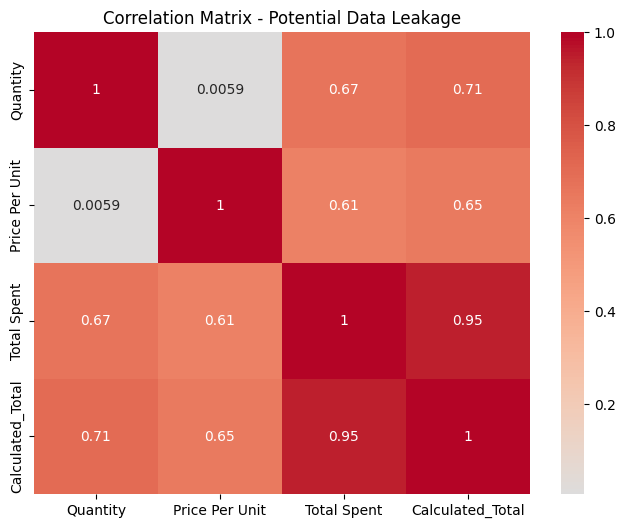

In [41]:
# Visualize correlations
plt.figure(figsize=(8, 6))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Potential Data Leakage')
plt.show()

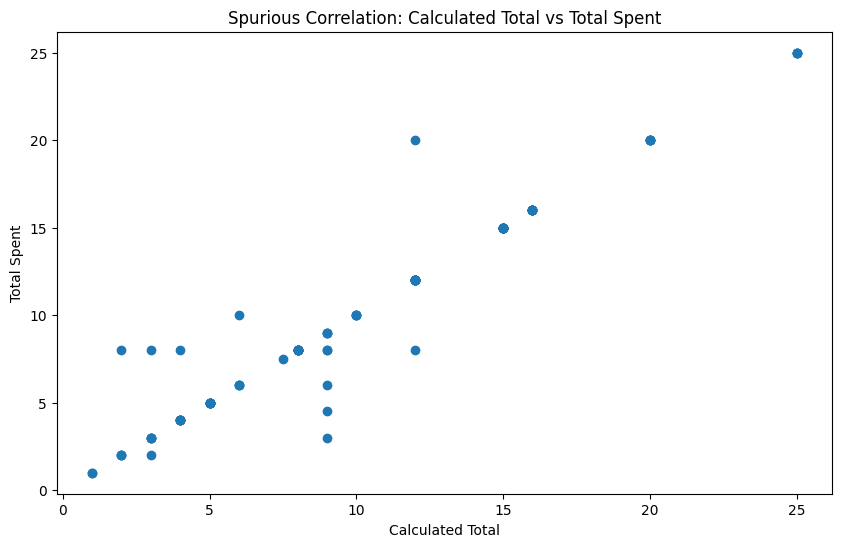

Correlation between Calculated_Total and Total Spent: 0.9462


In [42]:
plt.figure(figsize=(10, 6))
plt.scatter(df_analysis['Calculated_Total'].head(100), df_analysis['Total Spent'].head(100))
plt.xlabel('Calculated Total')
plt.ylabel('Total Spent')
plt.title('Spurious Correlation: Calculated Total vs Total Spent')
plt.show()

# Check correlation
id_correlation = df_analysis[['Calculated_Total', 'Total Spent']].corr()
print(f"Correlation between Calculated_Total and Total Spent: {id_correlation.iloc[0,1]:.4f}")

### Time-based leakage

In [ ]:
# If we sort by date, later transactions might have different patterns
df_analysis['Transaction Date'] = pd.to_datetime(df_analysis['Transaction Date'], errors='coerce')
df_sorted = df_analysis.sort_values('Transaction Date')

# Check if spending patterns change over time
df_sorted['Date_Ordinal'] = df_sorted['Transaction Date'].map(lambda x: x.toordinal() if pd.notnull(x) else np.nan)
time_corr = df_sorted[['Date_Ordinal', 'Total Spent']].corr()
print(f"Correlation between Date and Total Spent: {time_corr.iloc[0,1]:.4f}")

Correlation between Date and Total Spent: -0.0082


In [46]:
# Feature Engineering without leakage
# Create features that would be available at prediction time
df_features = df_analysis.copy()

# Day of week (available at prediction time)
df_features['Day_of_Week'] = df_features['Transaction Date'].dt.day_name()

# Hour of day (if we had time, but we don't)
# Is weekend
df_features['Is_Weekend'] = df_features['Day_of_Week'].isin(['Saturday', 'Sunday'])

# Item category (from our earlier labelling)
item_category_map = {
    'Coffee': 'Beverage', 'Tea': 'Beverage', 'Juice': 'Beverage', 'Smoothie': 'Beverage',
    'Sandwich': 'Food', 'Salad': 'Food', 'Cake': 'Dessert', 'Cookie': 'Dessert'
}
df_features['Item_Category'] = df_features['Item'].map(item_category_map)

print("Safe features for prediction:")
print(df_features[['Day_of_Week', 'Is_Weekend', 'Item_Category', 'Payment Method']].head())

Safe features for prediction:
  Day_of_Week  Is_Weekend Item_Category  Payment Method
0      Friday       False      Beverage     Credit Card
1     Tuesday       False       Dessert            Cash
2   Wednesday       False       Dessert     Credit Card
3    Thursday       False          Food  Digital Wallet
4      Sunday        True      Beverage  Digital Wallet


In [47]:
# If we were predicting Total Spent, we should not use features derived from the future
from sklearn.model_selection import TimeSeriesSplit

# Sort by date for time series split
df_ts = df.dropna(subset=['Transaction Date']).sort_values('Transaction Date')

# Time series split
tscv = TimeSeriesSplit(n_splits=3)
for i, (train_index, test_index) in enumerate(tscv.split(df_ts)):
    print(f"Fold {i+1}: Train size: {len(train_index)}, Test size: {len(test_index)}")
    # In practice, you'd train on train_index and validate on test_index

Fold 1: Train size: 2461, Test size: 2460
Fold 2: Train size: 4921, Test size: 2460
Fold 3: Train size: 7381, Test size: 2460


## 5. Train/Validation/Test Splits in Practice

Proper data splitting is crucial for model evaluation. We'll demonstrate different splitting strategies and their importance.

In [ ]:
# Prepare data for splitting
df_split = df_features.copy()

# Convert categorical variables to numeric for demonstration
le = LabelEncoder()
categorical_features = ['Item', 'Payment Method', 'Location', 'Item_Category', 'Day_of_Week']
for col in categorical_features:
    df_split[col] = le.fit_transform(df_split[col].astype(str))

# Select features and target
# Let's predict Total Spent based on available features
features = ['Quantity', 'Price Per Unit', 'Item', 'Payment Method', 'Location', 'Item_Category', 'Is_Weekend']
target = 'Total Spent'

df_ml = df_split[features + [target]].dropna()
X = df_ml[features]
y = df_ml[target]

print("Dataset for Modelling:")
print(f"Features: {features}")
print(f"Samples: {len(X)}")
print(f"Target distribution - Mean: {y.mean():.2f}, Std: {y.std():.2f}")

Dataset for ML:
Features: ['Quantity', 'Price Per Unit', 'Item', 'Payment Method', 'Location', 'Item_Category', 'Is_Weekend']
Samples: 10000
Target distribution - Mean: 8.88, Std: 5.86


In [ ]:
# Split 1: Simple random split (not recommended for time series)
X_train_rand, X_test_rand, y_train_rand, y_test_rand = train_test_split(X, y, test_size=0.2, random_state=42)
print(f"Random Split - Train: {len(X_train_rand)}, Test: {len(X_test_rand)}")

Random Split - Train: 8000, Test: 2000


In [49]:
# Split 2: Time-based split (better for time series data)
df_time = df_split.dropna(subset=['Transaction Date']).sort_values('Transaction Date')
df_time_ml = df_time[features + [target]].dropna()

# Use first 80% for training, last 20% for testing
split_idx = int(len(df_time_ml) * 0.8)
X_train_time = df_time_ml[features][:split_idx]
X_test_time = df_time_ml[features][split_idx:]
y_train_time = df_time_ml[target][:split_idx]
y_test_time = df_time_ml[target][split_idx:]

print(f"Time-based Split - Train: {len(X_train_time)}, Test: {len(X_test_time)}")

Time-based Split - Train: 7632, Test: 1908


In [50]:
# Split 3: Train/Validation/Test split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=42)  # 0.25 * 0.8 = 0.2

print(f"Train/Val/Test Split - Train: {len(X_train)}, Val: {len(X_val)}, Test: {len(X_test)}")

Train/Val/Test Split - Train: 6000, Val: 2000, Test: 2000


In [51]:
# Demonstrate stratified split for categorical target

# Example: Convert target to categorical for stratification
y_cat = pd.cut(y, bins=3, labels=['Low', 'Medium', 'High'])

X_train_strat, X_test_strat, y_train_strat, y_test_strat = train_test_split(
    X, y_cat, test_size=0.2, random_state=42, stratify=y_cat
)

print(f"Stratified Split - Train: {len(X_train_strat)}, Test: {len(X_test_strat)}")
print("Train distribution:", y_train_strat.value_counts(normalize=True))
print("Test distribution:", y_test_strat.value_counts(normalize=True))

Stratified Split - Train: 8000, Test: 2000
Train distribution: Total Spent
Low       0.635375
Medium    0.264125
High      0.100500
Name: proportion, dtype: float64
Test distribution: Total Spent
Low       0.6355
Medium    0.2640
High      0.1005
Name: proportion, dtype: float64


In [57]:
# Cross-validation demonstration
from sklearn.model_selection import KFold, cross_val_score

# K-Fold CV
kf = KFold(n_splits=5, shuffle=True, random_state=42)
print('Number of K splits:', kf.get_n_splits(X))
list(kf.split(X))

Number of K splits: 5


[(array([   1,    2,    4, ..., 9996, 9997, 9999], shape=(8000,)),
  array([   0,    3,    8, ..., 9989, 9993, 9998], shape=(2000,))),
 (array([   0,    1,    2, ..., 9997, 9998, 9999], shape=(8000,)),
  array([  26,   27,   30, ..., 9960, 9962, 9996], shape=(2000,))),
 (array([   0,    1,    3, ..., 9997, 9998, 9999], shape=(8000,)),
  array([   2,   15,   28, ..., 9980, 9985, 9995], shape=(2000,))),
 (array([   0,    1,    2, ..., 9996, 9997, 9998], shape=(8000,)),
  array([   6,    7,   16, ..., 9992, 9994, 9999], shape=(2000,))),
 (array([   0,    2,    3, ..., 9996, 9998, 9999], shape=(8000,)),
  array([   1,    4,    5, ..., 9987, 9988, 9997], shape=(2000,)))]


### KEY TAKEAWAYS:

1. Use time-based splits for time series data
2. Stratify when classes are imbalanced
3. Use cross-validation for robust evaluation
4. Never use test data for model selection
5. Validation set helps tune hyperparameters
6. Test set gives unbiased performance estimate